In [1]:
# ======================================
# IMPORT LIBRARIES
# ======================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# ======================================
# LOAD DATASET
# ======================================

df = pd.read_csv(
    "../dataset/loan_approval_dataset.csv"
)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# ======================================
# DATASET SHAPE
# ======================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 614
Columns: 13


In [4]:
# ======================================
# DATASET INFO
# ======================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [5]:
# ======================================
# DESCRIPTIVE STATISTICS
# ======================================

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
# ======================================
# MISSING VALUES
# ======================================

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
# ======================================
# HANDLE MISSING VALUES
# ======================================

for column in df.columns:

    if df[column].dtype == "object":

        df[column].fillna(
            df[column].mode()[0],
            inplace=True
        )

    else:

        df[column].fillna(
            df[column].median(),
            inplace=True
        )

print("Missing Values Handled")

Missing Values Handled


C:\Users\Matheesha Anjana\AppData\Local\Temp\ipykernel_57884\1714341008.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(
C:\Users\Matheesha Anjana\AppData\Local\Temp\ipykernel_57884\1714341008.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

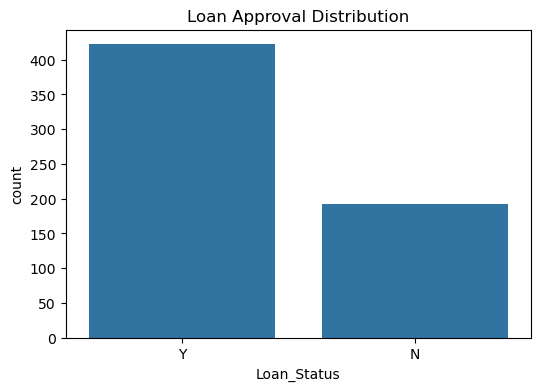

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Loan_Status",
    data=df
)

plt.title("Loan Approval Distribution")

plt.show()

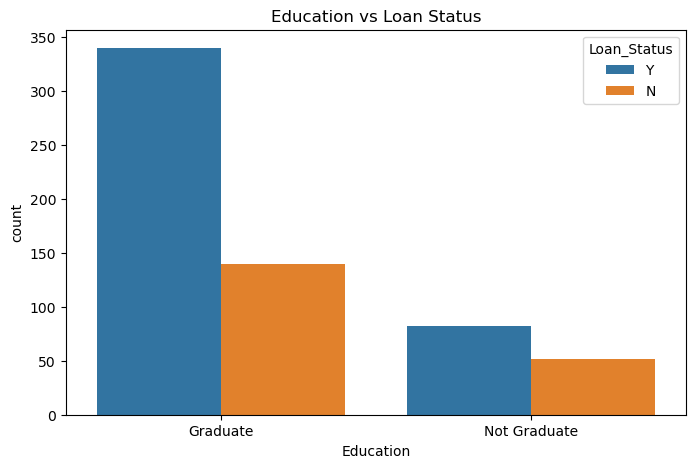

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Education",
    hue="Loan_Status",
    data=df
)

plt.title(
    "Education vs Loan Status"
)

plt.show()

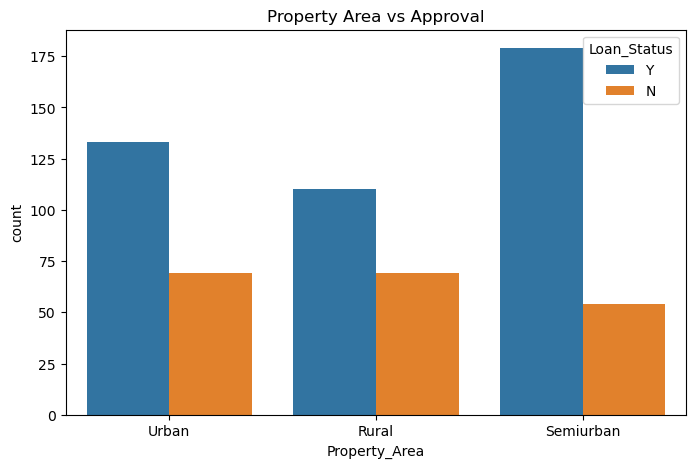

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Property_Area",
    hue="Loan_Status",
    data=df
)

plt.title(
    "Property Area vs Approval"
)

plt.show()

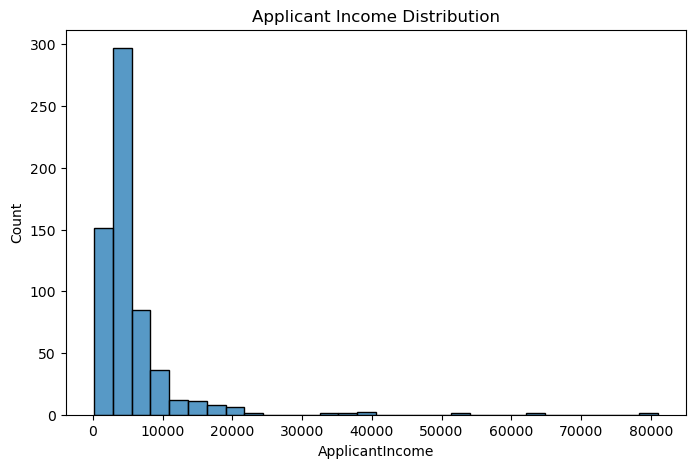

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ApplicantIncome"],
    bins=30
)

plt.title(
    "Applicant Income Distribution"
)

plt.show()

In [12]:
# ======================================
# LABEL ENCODING
# ======================================

encoder = LabelEncoder()

for col in df.select_dtypes(
    include="object"
).columns:

    df[col] = encoder.fit_transform(
        df[col]
    )

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [13]:
# ======================================
# FEATURE ENGINEERING
# ======================================

df["TotalIncome"] = (
    df["ApplicantIncome"] +
    df["CoapplicantIncome"]
)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


In [14]:
# ======================================
# FEATURES AND TARGET
# ======================================

X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]

In [15]:
# ======================================
# FEATURE SELECTION
# ======================================

selector = SelectKBest(
    score_func=chi2,
    k=5
)

selector.fit(abs(X), y)

scores = pd.DataFrame({

    "Feature": X.columns,

    "Score":
    selector.scores_

})

scores.sort_values(
    by="Score",
    ascending=False
)

,Feature,Score
7,CoapplicantIncome,11342.041603
12,TotalIncome,3559.550362
6,ApplicantIncome,93.904964
8,LoanAmount,32.821655
10,Credit_History,26.005877
0,Loan_ID,8.723627
9,Loan_Amount_Term,3.778554
4,Education,3.540502
2,Married,1.782425
11,Property_Area,0.377837


In [16]:
# ======================================
# SCALING
# ======================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,

    y,

    test_size=0.2,

    random_state=42
)

In [18]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)

acc_lr = accuracy_score(
    y_test,
    pred_lr
)

print(acc_lr)

0.7886178861788617


In [19]:
knn = KNeighborsClassifier()

knn.fit(
    X_train,
    y_train
)

pred_knn = knn.predict(
    X_test
)

acc_knn = accuracy_score(
    y_test,
    pred_knn
)

print(acc_knn)

0.7642276422764228


In [20]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

acc_rf = accuracy_score(
    y_test,
    pred_rf
)

print(acc_rf)

0.7804878048780488


In [21]:
params = {

    "n_neighbors":[
        3,5,7,9,11
    ]
}

grid = GridSearchCV(

    KNeighborsClassifier(),

    params,

    cv=5
)

grid.fit(
    X_train,
    y_train
)

print(
    grid.best_params_
)

print(
    grid.best_score_
)

{'n_neighbors': 11}
0.7962894248608535


In [22]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123



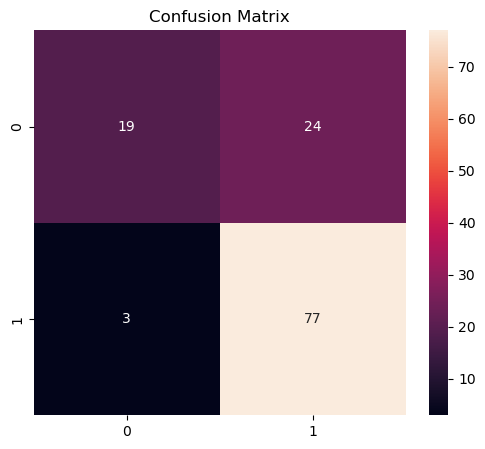

In [23]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [24]:
results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "KNN",

        "Random Forest"

    ],

    "Accuracy":[

        acc_lr,

        acc_knn,

        acc_rf

    ]

})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.788618
2,Random Forest,0.780488
1,KNN,0.764228


In [25]:
joblib.dump(
    rf,
    "../deployment/model.pkl"
)

joblib.dump(
    scaler,
    "../deployment/scaler.pkl"
)

print(
    "Model Saved"
)

Model Saved
